Fashion Recommendation system


In [1]:
!pip install seaborn
!pip install torch
!pip install torchvision
!pip install joblib
!pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Deep Learning

import torch
from torch.jit import ignore
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# image processing
import os
from pathlib import Path
import joblib
import time

# Machine Learning
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

# image processing
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette

# set Random seeds it is used for reproduceibilty (it make random operations determanistic)
np.random.seed(42)
torch.manual_seed(42)









In [3]:
# config 

USE_SUBSET = True
SUBSET_SIZE = 4000
BATCH_SIZE = 32


In [4]:
from pathlib import Path
import pandas as pd

image_dir = Path("/Users/tanmay/Desktop/Capstone/code/Trail/img/archive/myntradataset/images")

print("Exists:", image_dir.exists())

# Get ALL images (jpg + png)
image_paths = list(image_dir.rglob("*.jpg")) + list(image_dir.rglob("*.png"))

print("Images found:", len(image_paths))

fashion_data = []

for img_path in image_paths:
    fashion_data.append({
        "image_id": img_path.stem,
        "image_path": str(img_path),
        "filename": img_path.name
    })

fashion_df = pd.DataFrame(fashion_data)

print("DF shape:", fashion_df.shape)

if len(fashion_df) > 0:
    fashion_df = fashion_df.sample(min(SUBSET_SIZE, len(fashion_df)), random_state=42).reset_index(drop=True)
else:
    print(" No images found → path or file type is wrong")

fashion_df.head()

Exists: True
Images found: 53474
DF shape: (53474, 3)


,image_id,image_path,filename
0,21326,/Users/tanmay/Desktop/Capstone/code/Trail/img/...,21326.jpg
1,52828,/Users/tanmay/Desktop/Capstone/code/Trail/img/...,52828.jpg
2,4473,/Users/tanmay/Desktop/Capstone/code/Trail/img/...,4473.jpg
3,33524,/Users/tanmay/Desktop/Capstone/code/Trail/img/...,33524.jpg
4,33417,/Users/tanmay/Desktop/Capstone/code/Trail/img/...,33417.jpg


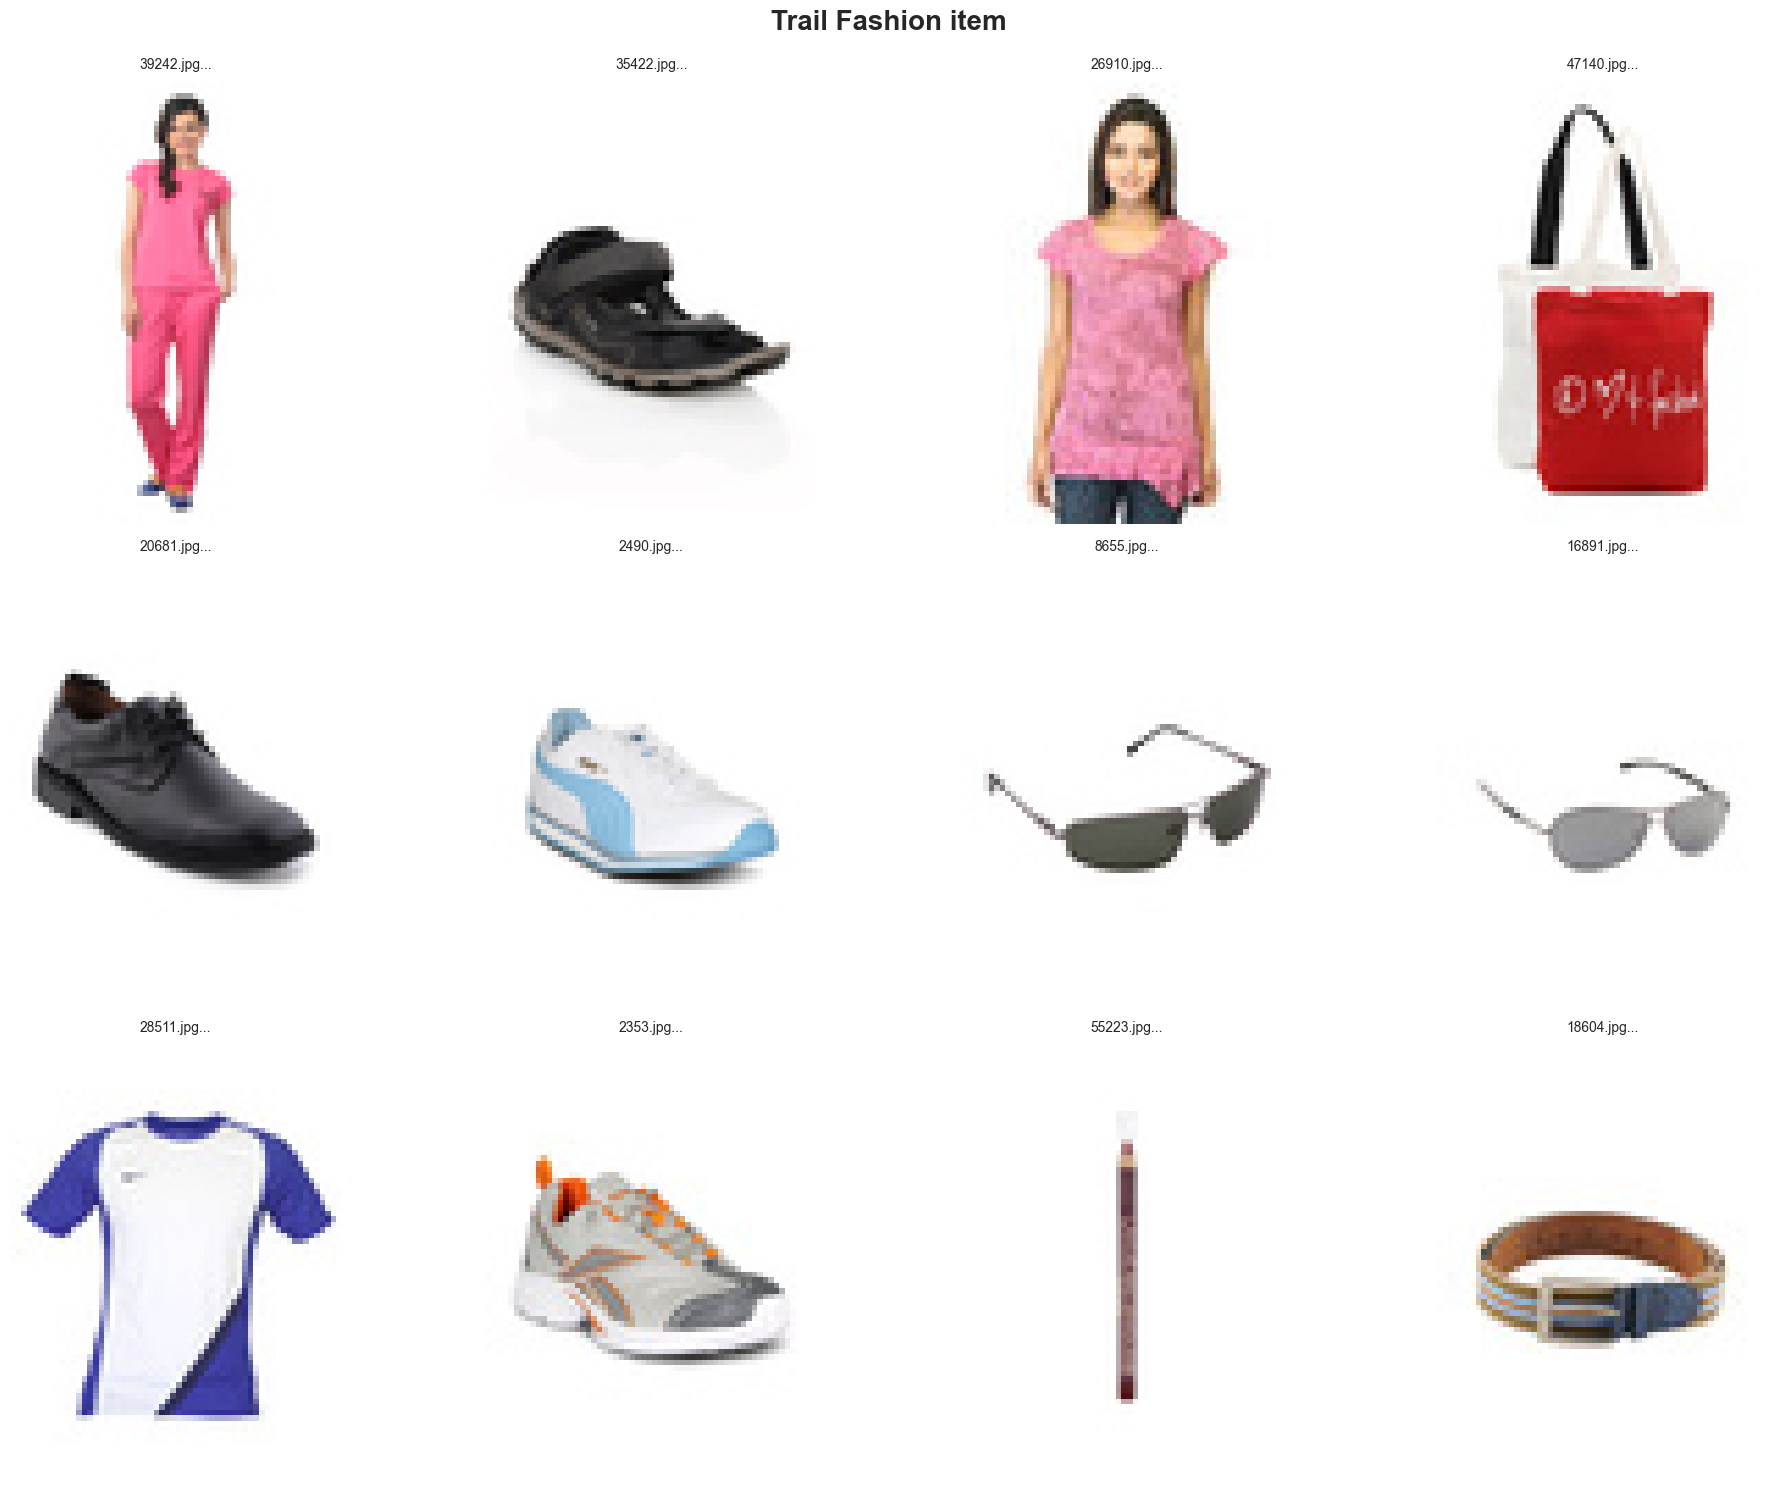

In [5]:
fig,axes = plt.subplots(3,4, figsize = (20,15))
fig.suptitle("Trail Fashion item", fontsize = 20, fontweight = 'bold', y=0.995)

sample_items = fashion_df.sample(min(12,len(fashion_df)))

for idx,(ax,(_, item)) in enumerate(zip(axes.flat, sample_items.iterrows())):
    try:
        img = Image.open(item['image_path'])
        ax.imshow(img)
        ax.set_title(f"{item    ['filename'][:25]}...", fontsize = 10, pad = 10)
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f'error loading{item["filename"][:20]}',ha = 'center', va = 'center', fontsize = 9)
        ax.axis("off")
plt.tight_layout()
plt.show()



In [6]:
subset_folder = Path("/Users/tanmay/Desktop/Capstone/code/Trail/img/archive/myntradataset/images")
subset_images_folder = subset_folder / "subset"
subset_csv_path = subset_folder / "subset_metadata.csv"

# ---------------------------
# 2. Load metadata again
# ---------------------------
fashion_df = pd.read_csv(subset_csv_path)

print("Loaded fashion_df shape:", fashion_df.shape)
print(fashion_df.head())

# ---------------------------
# 3. Rebuild image_path to point to subset folder
#    Assumes CSV has a 'filename' column
# ---------------------------
fashion_df["image_path"] = fashion_df["filename"].apply(lambda x: str(subset_images_folder / x))

# Keep only rows whose files actually exist
fashion_df = fashion_df[fashion_df["image_path"].apply(lambda x: Path(x).exists())].reset_index(drop=True)

print("After checking existing files:", fashion_df.shape)

# ---------------------------
# 4. Load ResNet18 feature extractor
# ---------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model = nn.Sequential(*list(model.children())[:-1])
model = model.to("cpu")
model.eval()

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ---------------------------
# 5. Feature extraction
# ---------------------------
BATCH_SIZE = 32
all_features = []
failed_images = []
start_time = time.time()

for i in range(0, len(fashion_df), BATCH_SIZE):
    batch_df = fashion_df.iloc[i:i + BATCH_SIZE]
    batch_images = []
    batch_filenames = []

    for _, row in batch_df.iterrows():
        try:
            img = Image.open(row["image_path"]).convert("RGB")
            img_tensor = transform(img)
            batch_images.append(img_tensor)
            batch_filenames.append(row["filename"])
        except Exception as e:
            failed_images.append(row["filename"])
            print(f"Failed: {row['image_path']} -> {e}")

    if batch_images:
        batch_tensor = torch.stack(batch_images).to("cpu")

        with torch.no_grad():
            features = model(batch_tensor)
            features = features.reshape(features.shape[0], -1).cpu().numpy()
            all_features.extend(features)

    if (i + BATCH_SIZE) % 200 == 0 or (i + BATCH_SIZE) >= len(fashion_df):
        elapsed_time = time.time() - start_time
        progress = min((i + BATCH_SIZE) / len(fashion_df), 1.0)
        print(
            f"Processed {min(i + BATCH_SIZE, len(fashion_df))}/{len(fashion_df)} "
            f"images in {elapsed_time:.2f} seconds ({progress:.2%})"
        )

# ---------------------------
# 6. Build final feature array
# ---------------------------
fashion_array = np.array(all_features)

# Remove failed images from dataframe
if failed_images:
    fashion_df = fashion_df[~fashion_df["filename"].isin(failed_images)].reset_index(drop=True)

elapsed_time = time.time() - start_time

print("\nFinished in", round(elapsed_time, 2), "seconds")
print("fashion_array shape:", fashion_array.shape)
print("successful images:", len(all_features))
print("failed images:", len(failed_images))

# ---------------------------
# 7. Fit nearest neighbors model
# ---------------------------
if len(fashion_array) > 0:
    knn_model = NearestNeighbors(
        n_neighbors=min(20, len(fashion_array)),
        metric="cosine",
        algorithm="brute"
    )
    knn_model.fit(fashion_array)
    print("NearestNeighbors model fitted successfully")
else:
    print("fashion_array is empty. Check CSV or image paths.")


Loaded fashion_df shape: (4000, 3)
   image_id                                         image_path   filename
0      2638  /Users/tanmay/Desktop/Capstone/code/Trail/img/...   2638.jpg
1     11826  /Users/tanmay/Desktop/Capstone/code/Trail/img/...  11826.jpg
2     36206  /Users/tanmay/Desktop/Capstone/code/Trail/img/...  36206.jpg
3     46114  /Users/tanmay/Desktop/Capstone/code/Trail/img/...  46114.jpg
4     33376  /Users/tanmay/Desktop/Capstone/code/Trail/img/...  33376.jpg
After checking existing files: (4000, 3)
Processed 800/4000 images in 11.48 seconds (20.00%)
Processed 1600/4000 images in 22.92 seconds (40.00%)
Processed 2400/4000 images in 34.23 seconds (60.00%)
Processed 3200/4000 images in 45.70 seconds (80.00%)
Processed 4000/4000 images in 57.80 seconds (100.00%)

Finished in 57.8 seconds
fashion_array shape: (4000, 512)
successful images: 4000
failed images: 0
NearestNeighbors model fitted successfully


In [7]:
n_test = min, len(fashion_df)

for test_num in range(n_test):
    test_idx = np.random.randint(0, len(fashion_df))
    query_item  = fashion_df.iloc[test_idx]

    query_features = fashion_array[test_idx].reshape(1,-1)
    distances, indices, = knn_model.kneighbors(query_features, n_neighbors=7)

    indices = indices[0][1:]
    distances = distances[0][1:]

    recommendations = fashion_df.iloc[indices].copy()
    recommendations['similarty'] = 1 - distances

    print("Top Recommendations")
    for i, (_,rec )



SyntaxError: invalid syntax (853352244.py, line 17)

In [ ]:
import torch.nn as nn
from torchvision import models, transforms

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model = nn.Sequential(*list(model.children())[:-1])
model = model.to('cpu')
model.eval()

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/tanmay/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


In [9]:
import time
import torch
import numpy as np
from PIL import Image

all_features = []
failed_images = []
start_time = time.time()

for i in range(0, len(fashion_df), BATCH_SIZE):
    batch_df = fashion_df.iloc[i:i + BATCH_SIZE]
    batch_images = []

    for idx, row in batch_df.iterrows():
        try:
            img = Image.open(row['image_path']).convert('RGB')
            img_tensor = transform(img)   # no unsqueeze here
            batch_images.append(img_tensor)

        except Exception as e:
            failed_images.append(row['filename'])
            print(f"Failed: {row['image_path']} -> {e}")
            continue

    if batch_images:
        batch_tensor = torch.stack(batch_images).to('cpu')

        with torch.no_grad():
            features = model(batch_tensor)
            features = features.reshape(features.shape[0], -1).cpu().numpy()
            all_features.extend(features)

    if (i + BATCH_SIZE) % 200 == 0 or (i + BATCH_SIZE) >= len(fashion_df):
        elapsed_time = time.time() - start_time
        progress = min((i + BATCH_SIZE) / len(fashion_df), 1.0)
        print(
            f"Processed {min(i + BATCH_SIZE, len(fashion_df))}/{len(fashion_df)} "
            f"images in {elapsed_time:.2f} seconds ({progress:.2%})"
        )

fashion_array = np.array(all_features)

if failed_images:
    fashion_df = fashion_df[
        ~fashion_df['filename'].isin(failed_images)
    ].reset_index(drop=True)

elapsed_time = time.time() - start_time

print(f"\nFinished in {elapsed_time:.2f} seconds")
print("fashion_array shape:", fashion_array.shape)
print("successful images:", len(all_features))
print("failed images:", len(failed_images))

Processed 800/4000 images in 11.57 seconds (20.00%)
Processed 1600/4000 images in 23.10 seconds (40.00%)
Processed 2400/4000 images in 34.59 seconds (60.00%)
Processed 3200/4000 images in 46.21 seconds (80.00%)
Processed 4000/4000 images in 58.33 seconds (100.00%)

Finished in 58.33 seconds
fashion_array shape: (4000, 512)
successful images: 4000
failed images: 0


In [ ]:
import time
import torch
import numpy as np
from PIL import Image

print("fashion_df shape before loop:", fashion_df.shape)
print("BATCH_SIZE:", BATCH_SIZE)

all_features = []
failed_images = []
start_time = time.time()

for i in range(0, len(fashion_df), BATCH_SIZE):
    print("Running batch starting at:", i)

    batch_df = fashion_df.iloc[i:i + BATCH_SIZE]
    batch_images = []

    for idx, row in batch_df.iterrows():
        try:
            img = Image.open(row['image_path']).convert('RGB')
            img_tensor = transform(img)
            batch_images.append(img_tensor)
        except Exception as e:
            failed_images.append(row['filename'])
            print(f"Failed: {row['image_path']} -> {e}")

    if batch_images:
        batch_tensor = torch.stack(batch_images).to("cpu")

        with torch.no_grad():
            features = model(batch_tensor)
            features = features.reshape(features.shape[0], -1).cpu().numpy()
            all_features.extend(features)

fashion_array = np.array(all_features)

print("fashion_array shape:", fashion_array.shape)
print("successful images:", len(all_features))
print("failed images:", len(failed_images))

fashion_df shape before loop: (0, 3)
BATCH_SIZE: 32
fashion_array shape: (0,)
successful images: 0
failed images: 0


In [11]:
# building k-nearest neighbors model

from sklearn.neighbors import NearestNeighbors


if len(fashion_array) == 0:
    print("❌ No data available. Fix dataset first.")
else:
    kmm_model = NearestNeighbors(
        n_neighbors=min(20, len(fashion_array)),
        metric='cosine',
        algorithm='brute',
    )
    
    kmm_model.fit(fashion_array)
    # print("✅ KNN model built successfully")



In [16]:
n_test = min(3, len(fashion_df))

for test_num in range(n_test):
    test_idx = np.random.randint(0, len(fashion_df))
    query_item = fashion_df.iloc[test_idx]

    query_features = fashion_array[test_idx].reshape(1, -1)
    distances, indices = knn_model.kneighbors(query_features, n_neighbors=7)

    indices = indices[0][1:]      # remove the query item itself
    distance = distances[0][1:]   # remove its distance too

    recommendations = fashion_df.iloc[indices].copy()
    recommendations['similarity'] = 1 - distance

    print("Query Item:", query_item['filename'])
    print("Top Recommendations")

    for i, (_, rec) in enumerate(recommendations.iterrows(), 1):
        print(f"{i}. {rec['filename']:35} | Similarity: {rec['similarity']:.4f}")

    print()

Query Item: 17997.jpg
Top Recommendations
1. 45489.jpg                           | Similarity: 0.9484
2. 17947.jpg                           | Similarity: 0.9471
3. 26504.jpg                           | Similarity: 0.9465
4. 26258.jpg                           | Similarity: 0.9440
5. 39812.jpg                           | Similarity: 0.9414
6. 16062.jpg                           | Similarity: 0.9356

Query Item: 12586.jpg
Top Recommendations
1. 24913.jpg                           | Similarity: 0.9044
2. 12599.jpg                           | Similarity: 0.9039
3. 12845.jpg                           | Similarity: 0.8960
4. 4868.jpg                            | Similarity: 0.8959
5. 4870.jpg                            | Similarity: 0.8954
6. 4723.jpg                            | Similarity: 0.8939

Query Item: 47652.jpg
Top Recommendations
1. 31068.jpg                           | Similarity: 0.8731
2. 49652.jpg                           | Similarity: 0.8617
3. 40195.jpg                    

Query Item: 30335.jpg
Top Recommendations


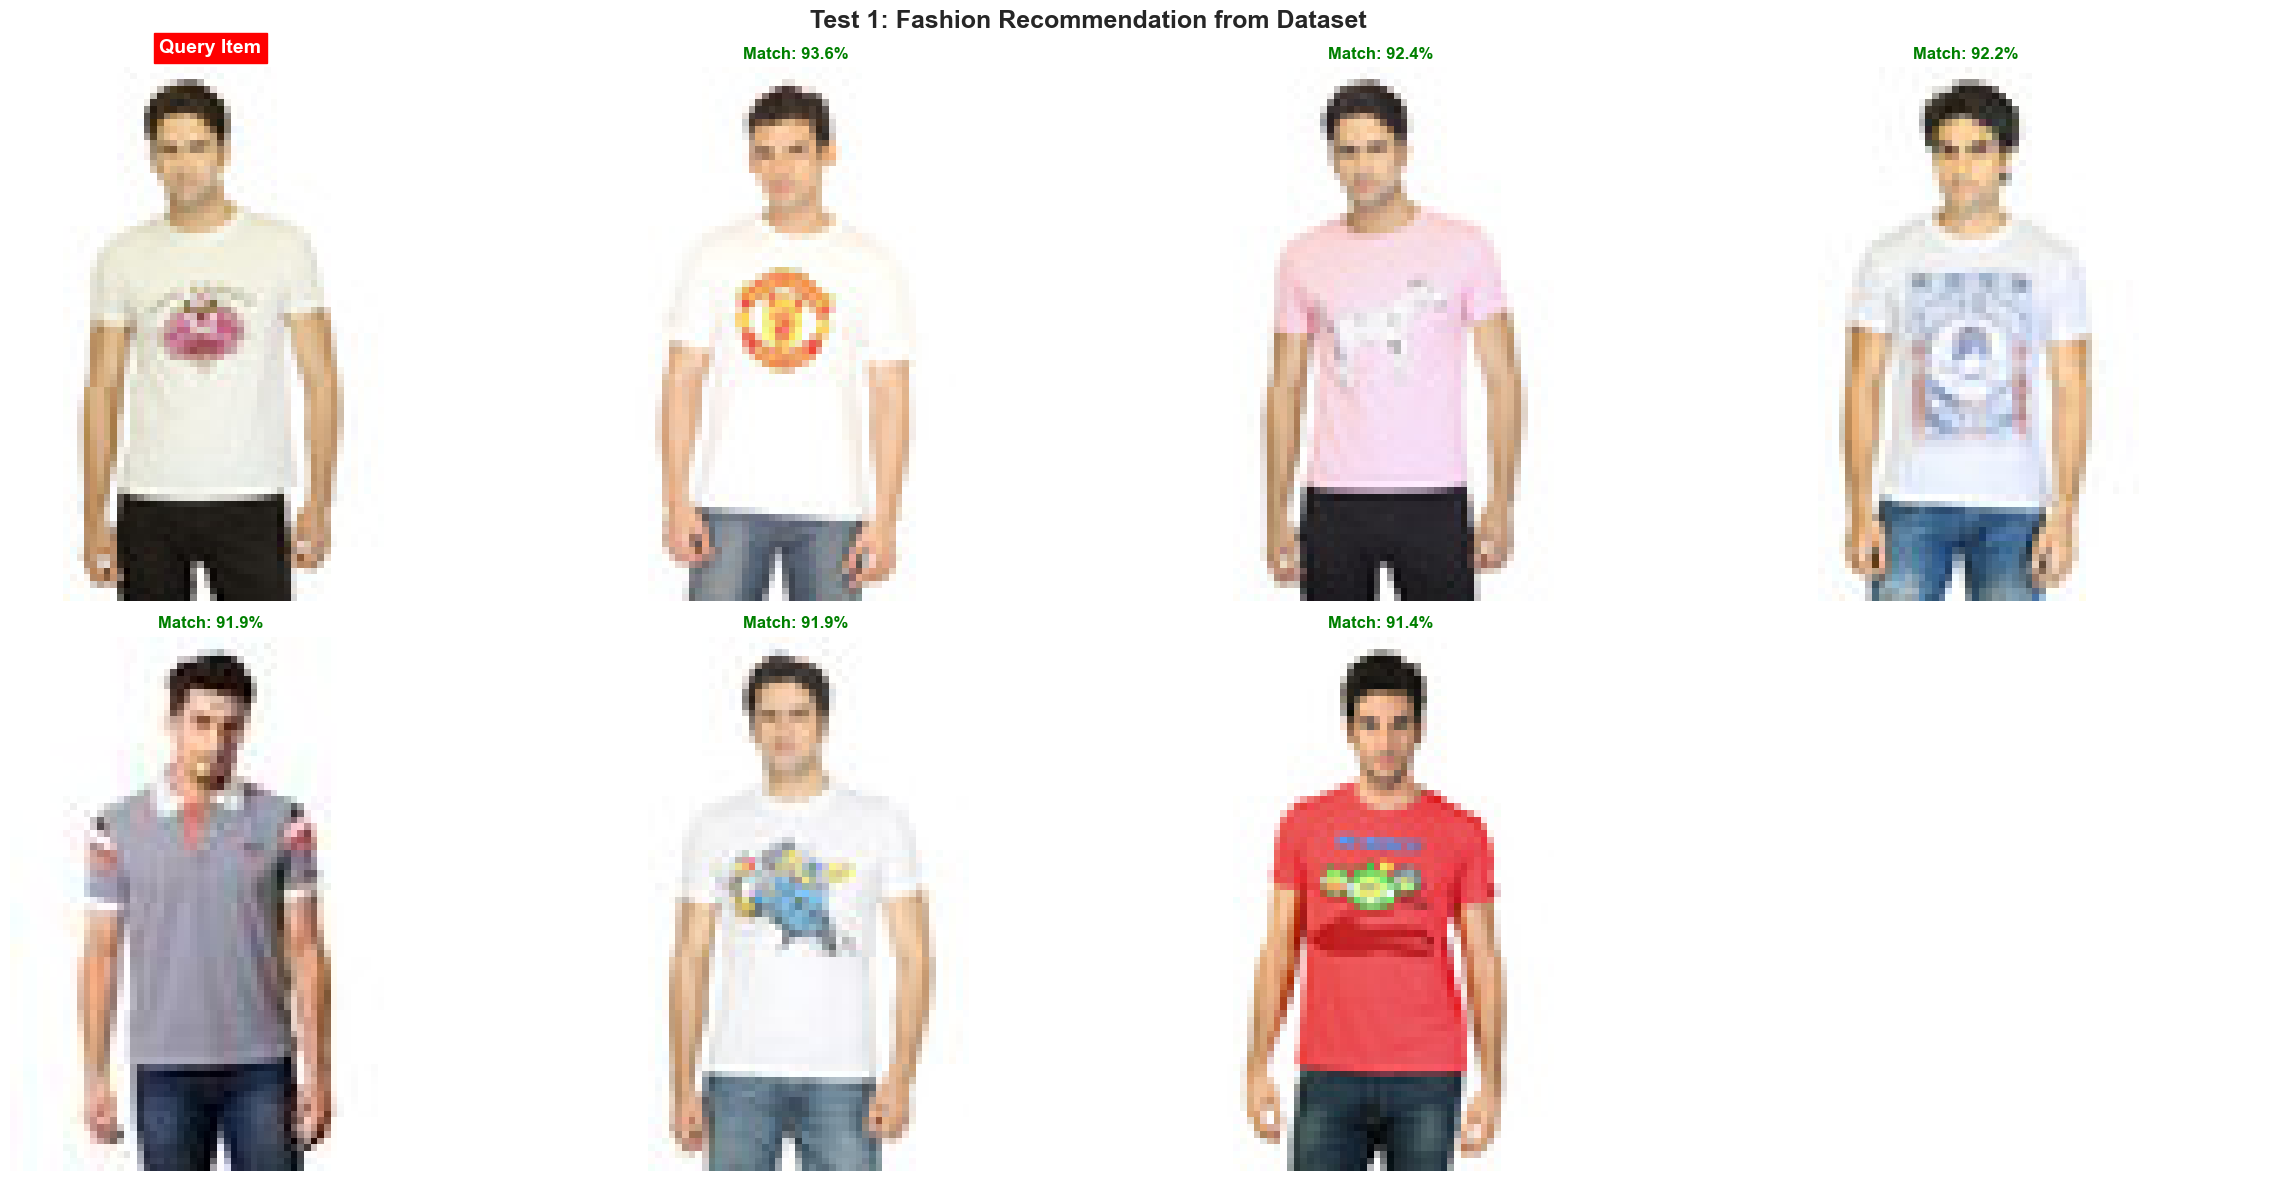

Query Item: 5507.jpg
Top Recommendations


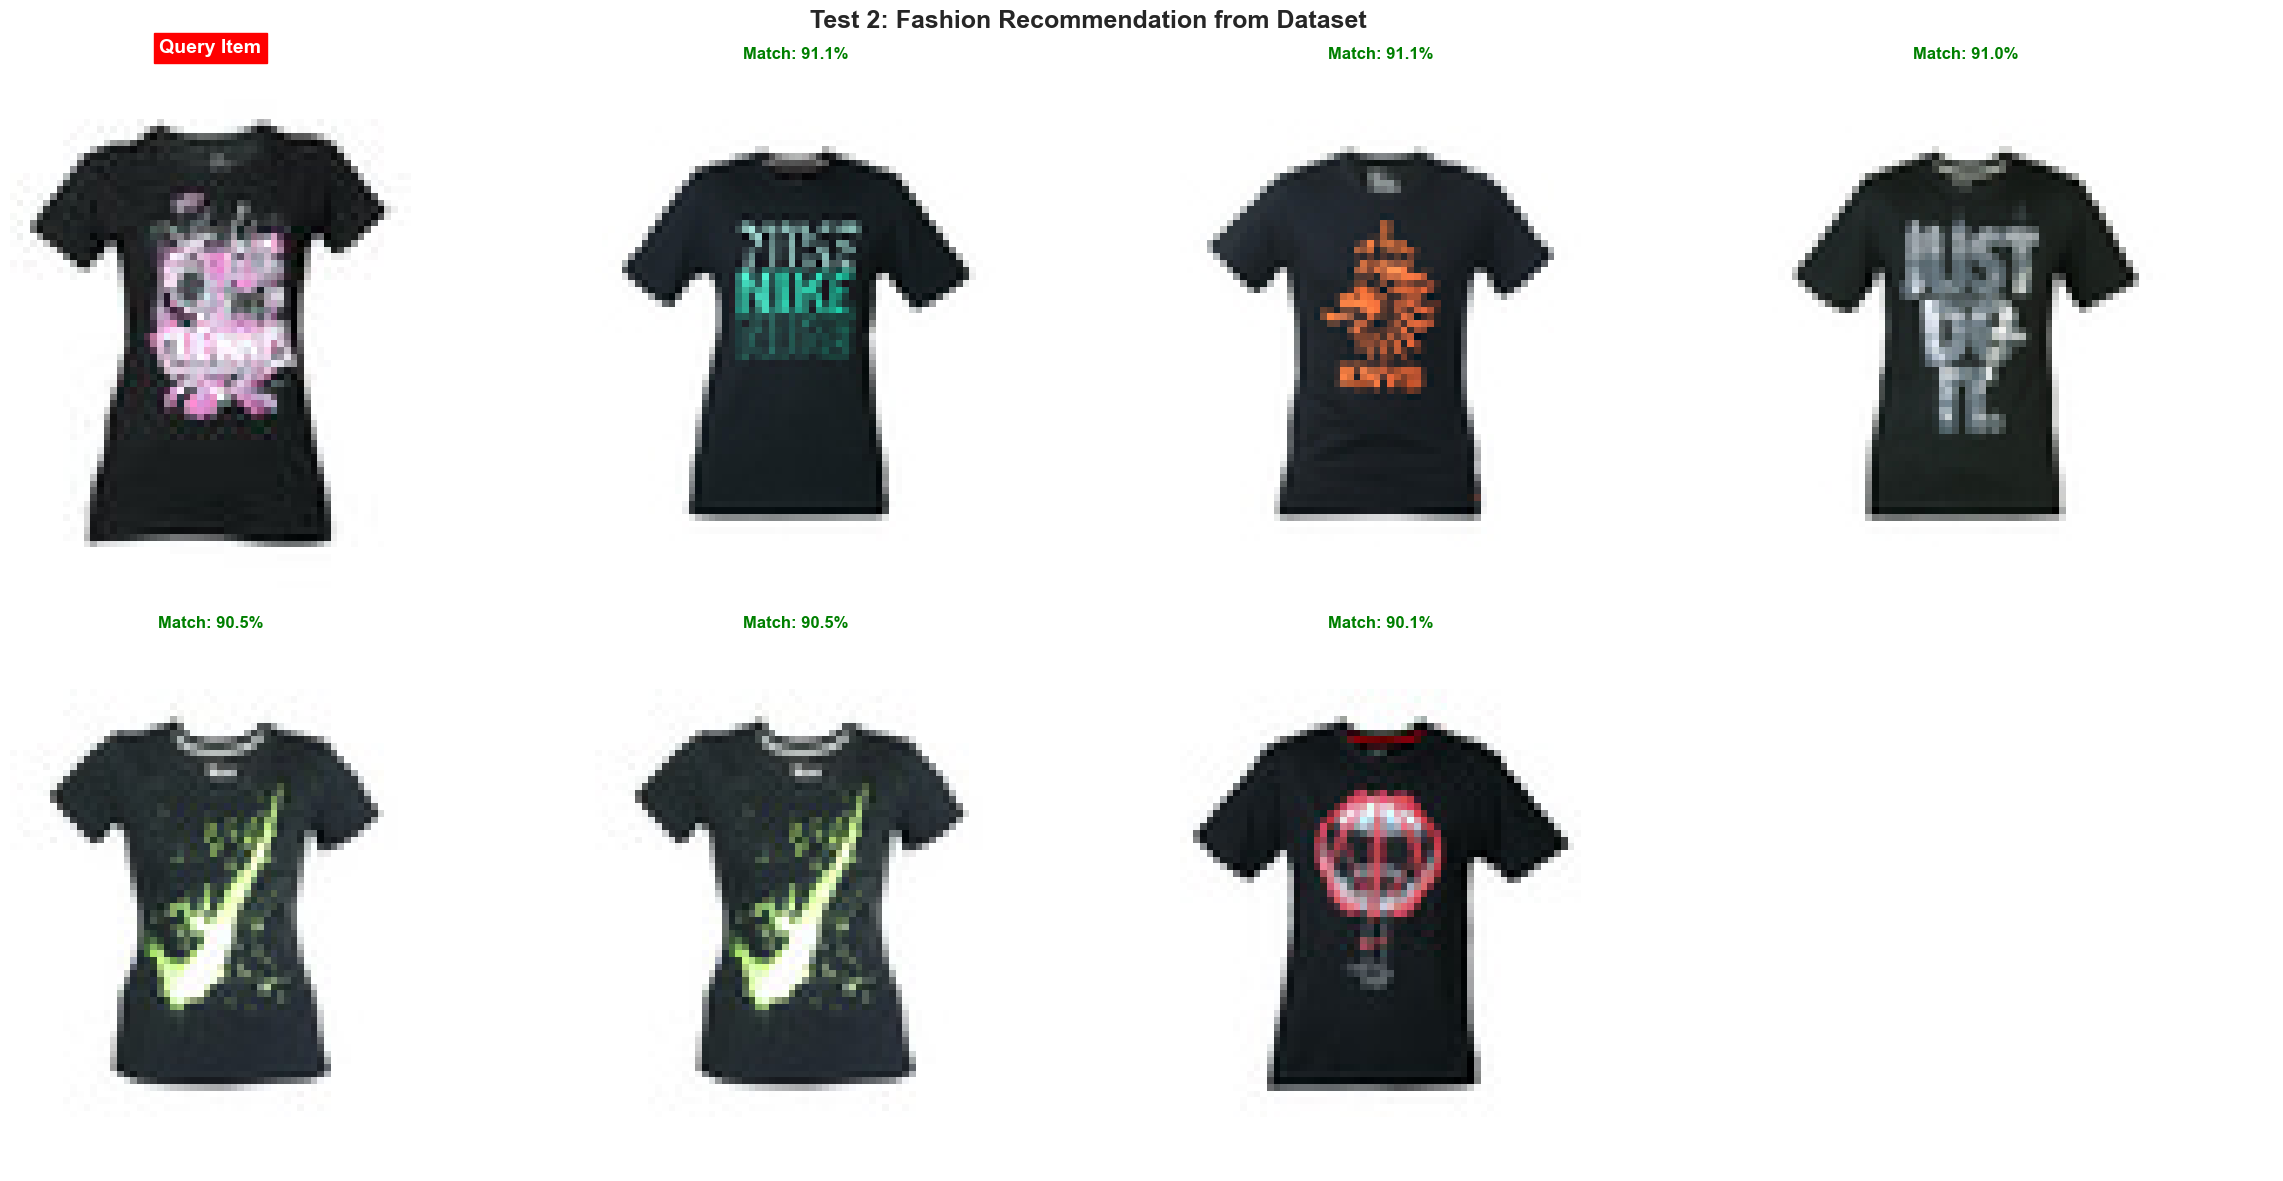

Query Item: 37296.jpg
Top Recommendations


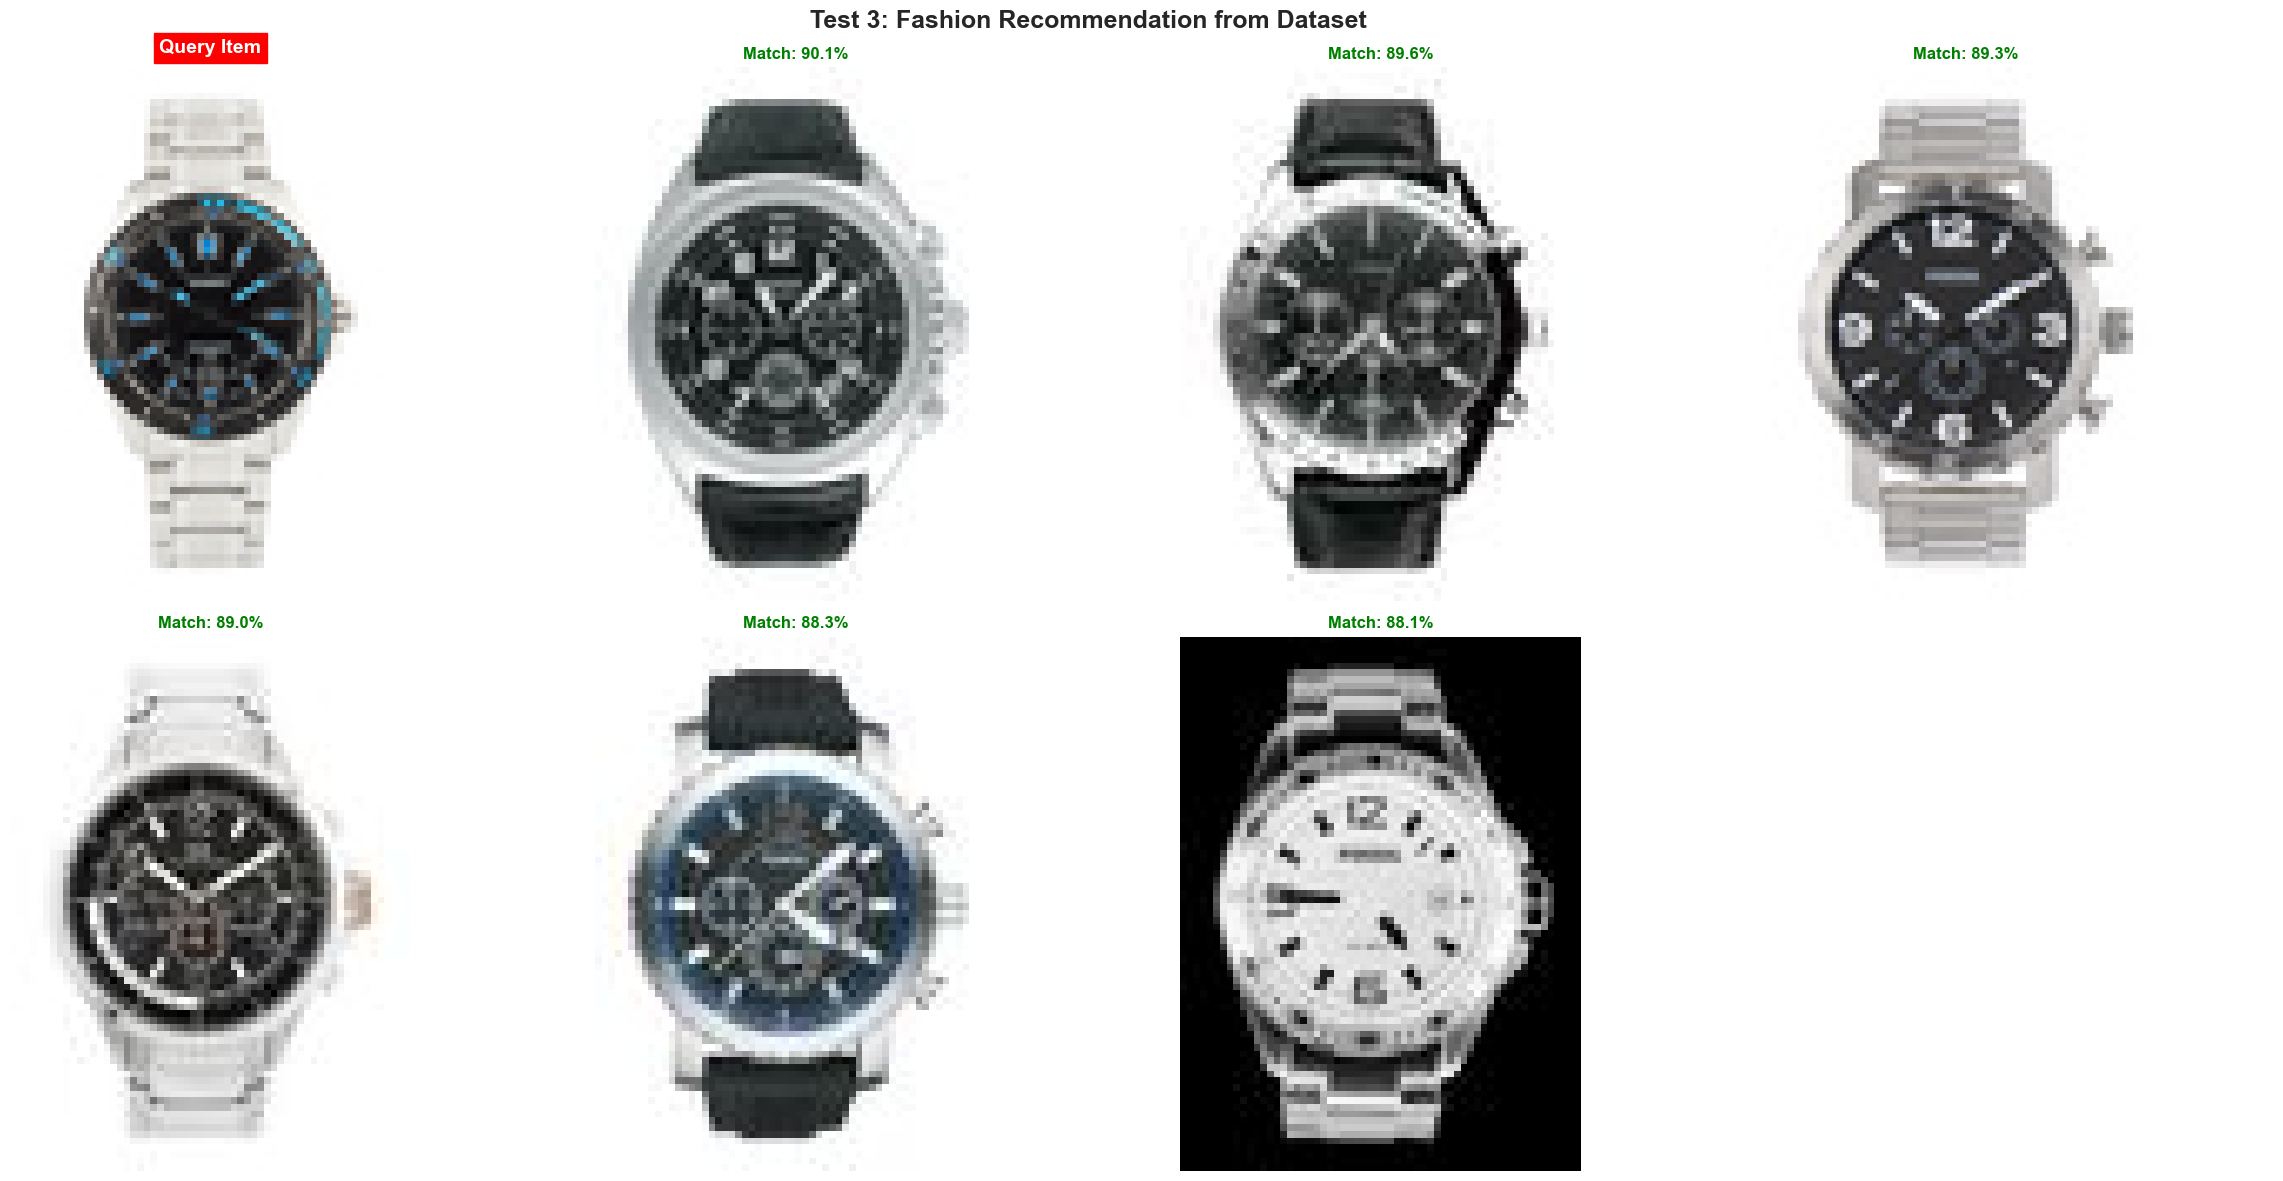

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

n_test = min(3, len(fashion_df))

for test_num in range(n_test):
    test_idx = np.random.randint(0, len(fashion_df))
    query_item = fashion_df.iloc[test_idx]

    query_features = fashion_array[test_idx].reshape(1, -1)
    distances, indices = knn_model.kneighbors(query_features, n_neighbors=7)

    indices = indices[0][1:]      # remove query item itself
    distances = distances[0][1:]  # remove query distance itself

    recommendations = fashion_df.iloc[indices].copy()
    recommendations['similarity'] = 1 - distances

    print("Query Item:", query_item['filename'])
    print("Top Recommendations")

    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle(
        f"Test {test_num + 1}: Fashion Recommendation from Dataset",
        fontsize=18,
        fontweight='bold'
    )

    # Show query image
    try:
        query_img = Image.open(query_item['image_path'])
        axes[0, 0].imshow(query_img)
        axes[0, 0].set_title(
            'Query Item',
            fontweight='bold',
            fontsize=14,
            color='white',
            backgroundcolor='red',
            pad=10
        )
        axes[0, 0].axis('off')

    except Exception as e:
        axes[0, 0].text(0.5, 0.5, "Error", ha='center', va='center')
        axes[0, 0].axis('off')
        print("Error loading query image:", e)

    # Show recommended images
    for idx, (ax, (_, rec)) in enumerate(zip(axes.flat[1:], recommendations.iterrows())):
        try:
            rec_img = Image.open(rec['image_path'])
            ax.imshow(rec_img)
            ax.set_title(
                f"Match: {rec['similarity']:.1%}",
                fontsize=12,
                fontweight='bold',
                color='green'
            )
            ax.axis('off')

        except Exception as e:
            ax.text(0.5, 0.5, "Error", ha='center', va='center')
            ax.axis('off')
            print(f"Error loading recommended image {idx+1}:", e)

    # Turn off any unused subplot
    for ax in axes.flat[len(recommendations) + 1:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [22]:
import os
import numpy as np
import joblib

# create folder
os.makedirs('models', exist_ok=True)

# save features
np.save('models/fashion_features.npy', fashion_array)

# save metadata
fashion_df.to_csv('models/fashion_metadata.csv', index=False)

# model data
model_data = {
    'features': fashion_array,
    'metadata': fashion_df,
    'feature_extractor_type': 'resnet18',
    'dataset': 'Trail',
    'num_items': len(fashion_df),
    'features_dim': fashion_array.shape[1]   
}

# save model
joblib.dump(model_data, 'models/fashion_recommender.pkl') 

# check file size
file_size = os.path.getsize('models/fashion_recommender.pkl') / (1024**2)

print(f"Model saved successfully! Size: {file_size:.2f} MB")

Model saved successfully! Size: 8.25 MB
